---
title: "Intro to EDA"
date: last-modified
toc: true
format:
  html: default
  ipynb: default
---


Exploratory data analysis, or EDA, is a standard practice prior to any data manipulation and analysis.

Recall that data engineering is primarily about data preparation to *serve* smooth and effective data analysis.  Exploratory data analysis generally refers to the step of understanding the data:  

- **summarizing characteristics of raw data**
- **visualizing data (single and multiple variables)**
- identifying missing data
- identifying outliers

This document primarily deals with the first two items.  

## Goals
In the **exploratory** phase, these are for people behind the scenes to see.  

The main goals here are:

- capture main message
- (relatively) quick exploration across many summaries (including plots)
- *not* intended for a client or presentation

What does this translate to, technically?

- each summary should have meaningful information
- **label** your plots

## Data summary
As a starting point, simply looking at the data is worth the while.  Some common questions to consider are the following:  


1. General dataset info: size, dtypes  
2. Missing values?  
3. Duplicate data?  
4. Continuous variables  
5. Categorical variables  
6. Bivariate relationships  
7. Potential data quality issues, e.g., inconsistency, special NA characters

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

|![sns](../img/sns.jpg)|
|:---:|
|[The origin of sns.](https://seaborn.pydata.org/faq.html#why-is-seaborn-imported-as-sns)|

## Earthquake dataset

[Source Link](https://open.canada.ca/data/en/dataset/2c3672b6-4c17-4ff5-9861-29e2dd6d03b3/resource/9cfea46f-561a-440f-9d17-fed3557fc7b5)

In [4]:
# load and save a copy of the earthquake dataset
earthquake = pd.read_csv('https://raw.githubusercontent.com/mosesyhc/de300-2026wi/refs/heads/main/datasets/Canadian-Earthquakes-2010-2019.csv')

In [5]:
# take a glimpse of the data
earthquake.head()

,magnitude_codelist,magnitude,magnitude_type,date,place,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
0,<2,1.7,ML,2010-01-01T00:16:49+0000,81 km NE of Seattle,0.0,48.192001,-121.677002,1,-121.677315,48.191706
1,2,2.2,MN,2010-01-01T00:52:50+0000,86 km NW from Maniwaki,18.0,47.028999,-76.583000,2,-76.583303,47.028909
2,<2,1.8,MN,2010-01-01T03:21:58+0000,21 km NW from Mont-Laurier,18.0,46.651001,-75.734001,3,-75.733902,46.650809
3,<2,1.5,MN,2010-01-01T04:14:51+0000,CHARLEVOIX SEISMIC ZONE,13.0,47.740002,-69.741997,4,-69.742000,47.740210
4,<2,1.6,ML,2010-01-01T04:15:17+0000,83 km W of Gold R.,11.6,49.500999,-127.222000,5,-127.222216,49.500705


In [6]:
# view a summary of the full data
earthquake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44561 entries, 0 to 44560
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   magnitude_codelist  44561 non-null  object 
 1   magnitude           44561 non-null  float64
 2   magnitude_type      44462 non-null  object 
 3   date                44561 non-null  object 
 4   place               44561 non-null  object 
 5   depth               44561 non-null  float64
 6   latitude            44561 non-null  float64
 7   longitude           44561 non-null  float64
 8   OBJECTID            44561 non-null  int64  
 9   longitude_geom      44561 non-null  float64
 10  latitude_geom       44561 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 3.7+ MB


In [7]:
# checks for duplicates (also ask if duplicates make sense)
earthquake.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
44556,False
44557,False
44558,False
44559,False


In [8]:
# duplicates


In [9]:
# a quick numerical summary
earthquake.describe()

,magnitude,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
count,44561.000000,44561.000000,44561.000000,44561.000000,44561.000000,44561.000000,44561.000000
mean,2.134070,12.852194,53.351863,-118.953322,22281.000000,-118.953299,53.351830
std,0.828096,9.963145,6.214464,23.696484,12863.797009,23.696493,6.214465
min,-1.400000,-0.500000,40.808998,-148.811005,1.000000,-148.810526,40.808509
25%,1.600000,5.000000,49.169998,-132.427994,11141.000000,-132.427618,49.170009
50%,2.100000,10.000000,52.137001,-129.671997,22281.000000,-129.672016,52.136507
75%,2.700000,18.000000,56.514999,-121.947998,33421.000000,-121.948318,56.515206
max,7.700000,214.000000,82.608002,-39.320000,44561.000000,-39.319968,82.607812


In [10]:
# checks for possible statistical assumption(s)
import scipy.stats as sps

sps.normaltest(earthquake['magnitude'])

NormaltestResult(statistic=np.float64(1597.6658124732553), pvalue=np.float64(0.0))

In [11]:
# extract only numeric variables
earthquake_num = earthquake.select_dtypes(include='number')
earthquake_num.head()

,magnitude,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
0,1.7,0.0,48.192001,-121.677002,1,-121.677315,48.191706
1,2.2,18.0,47.028999,-76.583000,2,-76.583303,47.028909
2,1.8,18.0,46.651001,-75.734001,3,-75.733902,46.650809
3,1.5,13.0,47.740002,-69.741997,4,-69.742000,47.740210
4,1.6,11.6,49.500999,-127.222000,5,-127.222216,49.500705


In [12]:
earthquake_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44561 entries, 0 to 44560
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   magnitude       44561 non-null  float64
 1   depth           44561 non-null  float64
 2   latitude        44561 non-null  float64
 3   longitude       44561 non-null  float64
 4   OBJECTID        44561 non-null  int64  
 5   longitude_geom  44561 non-null  float64
 6   latitude_geom   44561 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 2.4 MB


In [13]:
# for example, normality test


In [14]:
# for example, another normality test
import numpy as np

sps.normaltest(np.log(earthquake_num['magnitude']))

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


NormaltestResult(statistic=np.float64(nan), pvalue=np.float64(nan))

In [19]:
# pairwise correlation
earthquake_corr = earthquake_num.corr()
earthquake_corr

,magnitude,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
magnitude,1.000000,-0.127958,0.196699,-0.110731,-0.006523,-0.110731,0.196699
depth,-0.127958,1.000000,-0.107744,-0.005796,-0.103983,-0.005796,-0.107744
latitude,0.196699,-0.107744,1.000000,-0.266265,-0.000391,-0.266265,1.000000
longitude,-0.110731,-0.005796,-0.266265,1.000000,0.049094,1.000000,-0.266265
OBJECTID,-0.006523,-0.103983,-0.000391,0.049094,1.000000,0.049093,-0.000390
longitude_geom,-0.110731,-0.005796,-0.266265,1.000000,0.049093,1.000000,-0.266265
latitude_geom,0.196699,-0.107744,1.000000,-0.266265,-0.000390,-0.266265,1.000000


## Data visualization

In [26]:
sns.set(context='talk', style='ticks')  # simply for aesthetics
sns.set_palette('magma')
%matplotlib inline

earthquake = earthquake.sample(n=500)  # (if too slow) for illustration purposes

earthquake.head()

,magnitude_codelist,magnitude,magnitude_type,date,place,depth,latitude,longitude,OBJECTID,longitude_geom,latitude_geom
34549,<2,1.5,ML,2017-08-05T07:16:29+0000,69 SW of Sandspit,14.4,52.675999,-132.207993,34550,-132.208018,52.676005
10839,2,2.4,MN,2012-05-04T08:45:54+0000,55 km N from Fort Ross,18.0,72.480003,-93.839996,10840,-93.840120,72.479510
22655,2,2.3,ML,2015-02-10T22:51:09+0000,161 km NW of Prince George,11.6,55.117001,-124.140999,22656,-124.140818,55.117106
12105,3,3.0,Mw,2012-10-11T08:54:24+0000,201 km WSW of Bella Bella,10.0,51.007999,-130.378998,12106,-130.378817,51.008105
34821,<2,1.5,MN,2017-08-31T02:58:35+0000,63 SW from Bathurst,5.0,47.282001,-66.288002,34822,-66.287999,47.282010


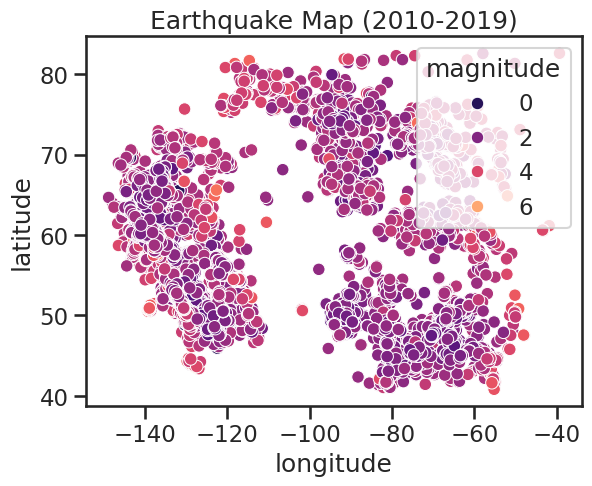

In [24]:
# histogram for continuous variables using pandas built-in plots
sns.scatterplot(data=earthquake, x='longitude', y='latitude', hue='magnitude', palette='magma')
plt.title('Earthquake Map (2010-2019)')
plt.show()

<Axes: xlabel='longitude', ylabel='latitude'>

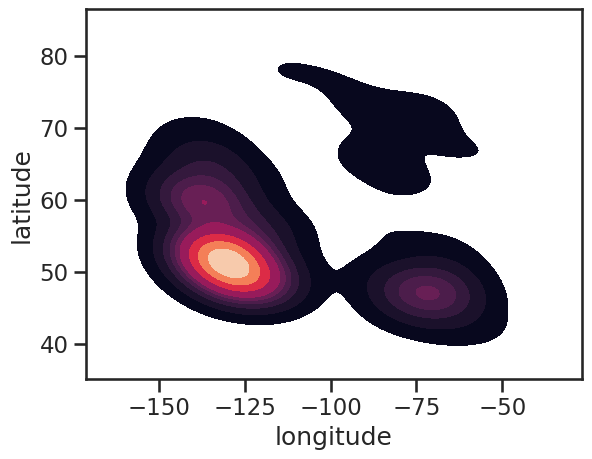

In [27]:
# relative frequency? ...
sns.kdeplot(data=earthquake, x='longitude', y='latitude', fill=True, cmap='rocket')

In [ ]:
# histogram of masses by group
import seaborn as sns
import matplotlib.pyplot as plt

# Sample Data
data = earthquake

# Create a figure and axis


sns.set_style("whitegrid") # Automatically adds the grid
plt.figure(figsize=(6, 6))

# markers=True adds the dots
sns.lineplot(data=data, x='Year', y='Count', marker='o')

plt.title('Earthquakes per Year')
plt.show()

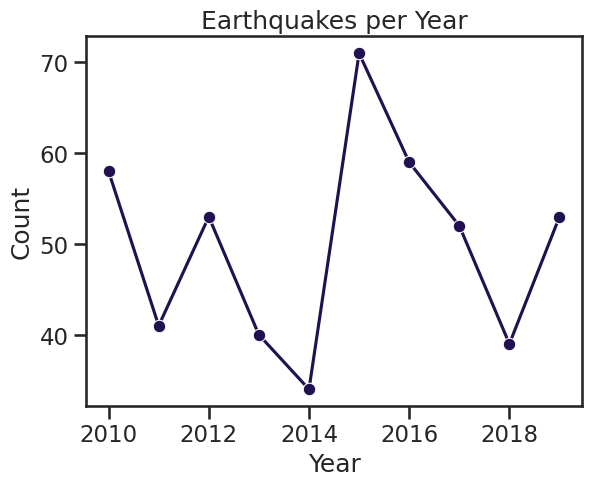

In [50]:
# other types of plots
years = pd.to_datetime(earthquake['date'])
sorted_years = years.dt.year.value_counts().sort_index().reset_index()
sorted_years.columns = ['Year', 'Count']

sns.lineplot(data=sorted_years, x='Year', y='Count', marker='o')
plt.title('Earthquakes per Year')
plt.show()

In [51]:
# counts for categorical variables
earthquake.columns

Index(['magnitude_codelist', 'magnitude', 'magnitude_type', 'date', 'place',
       'depth', 'latitude', 'longitude', 'OBJECTID', 'longitude_geom',
       'latitude_geom'],
      dtype='object')

In [52]:
# fun interactive map
import folium
from folium.plugins import HeatMap

m = folium.Map(location=[0, 0], zoom_start=2)

# Add the heat
heat_data = [[row['latitude'], row['longitude']] for index, row in earthquake.iterrows()]
HeatMap(heat_data).add_to(m)

m

In [ ]:
# bivariate plots

In [ ]:
# bivariate plots (log-log)

In [ ]:
# pairwise plots  (time-consuming)

In [ ]:
# another pairwise plot by group

## In-class activity
Refer to the following figure, choose two subfigures to reproduce with the earthquake dataset.

![](../datasets/earthquake_analysis-2010-2019.png)

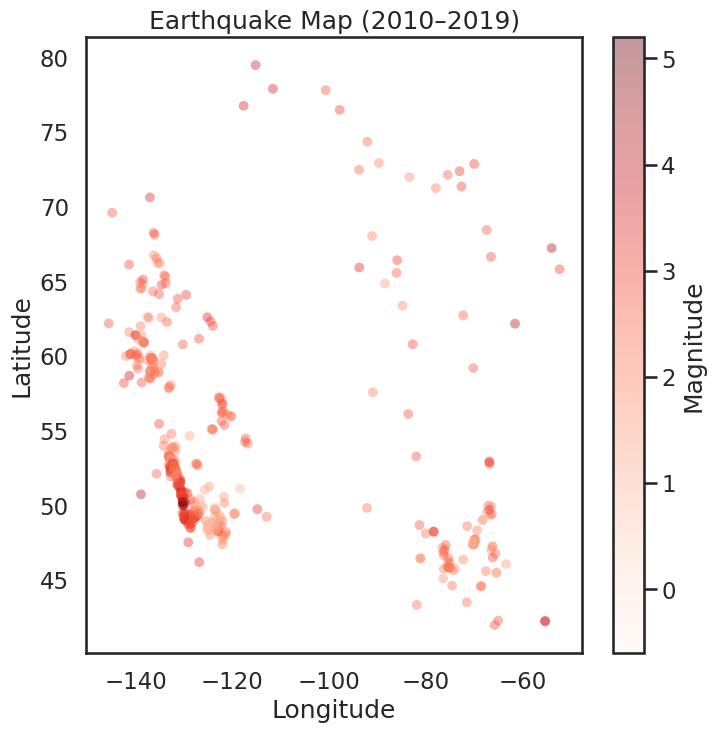

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))

scatter = plt.scatter(earthquake['longitude'], earthquake['latitude'],
                      c=earthquake['magnitude'], cmap='Reds',
                      alpha=0.4, edgecolors='none', s=50)
cbar = plt.colorbar(scatter)
cbar.set_label('Magnitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Earthquake Map (2010–2019)')

plt.show()

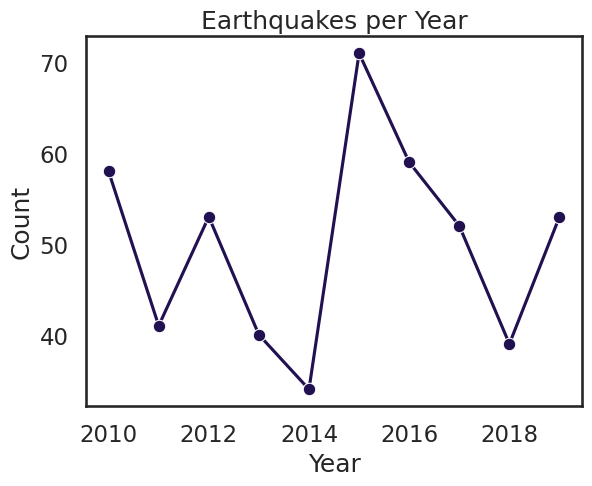

In [58]:
years = pd.to_datetime(earthquake['date'])
sorted_years = years.dt.year.value_counts().sort_index().reset_index()
sorted_years.columns = ['Year', 'Count']

sns.lineplot(data=sorted_years, x='Year', y='Count', marker='o')
plt.title('Earthquakes per Year')
plt.show()

## (In case you need this) Jupyter notebook setup

Visit https://docs.jupyter.org/en/latest/install/notebook-classic.html for some guidance to set up jupyter notebook.


---

*Note:* These notes are adapted from a blog post on [Tom's Blog](https://tomaugspurger.net/posts/modern-6-visualization/).
